In [39]:
"""
Tunisian Dialect Data Collection Pipeline
==========================================
Stage 1: Download, combine, and clean data from HuggingFace sources.

This notebook:
1. Loads datasets from HuggingFace
2. Combines them into one large corpus
3. Applies cleaning transformations
4. Saves processed data for pre-training (Stage 2)
"""

import sys
import importlib
import pandas as pd
import json
from pathlib import Path

# Make local scripts importable regardless of notebook launch directory
# Works in VS Code and Jupyter Lab/Notebook
scripts_dir = Path(r"C:\Users\user\OneDrive\Bureau\PFA\tunisian-dialogue-system\llm\data\scripts")
if not (scripts_dir / "data_loader.py").exists():
    candidate = Path.cwd() / "llm" / "data" / "scripts"
    if candidate.exists() and (candidate / "data_loader.py").exists():
        scripts_dir = candidate

if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

# Import and force-reload local modules to avoid stale notebook kernel imports
import data_loader
import data_cleaning
importlib.reload(data_loader)
importlib.reload(data_cleaning)

from data_loader import load_all_datasets, print_dataset_info
from data_cleaning import (
    full_cleaning_pipeline,
    filter_by_script_type,
    classify_text_type,
    get_top_words,
    count_tokens,
    print_cleaning_report,
)

print("✅ Imports successful!")
print(f"📁 Using scripts directory: {scripts_dir}")

✅ Imports successful!
📁 Using scripts directory: C:\Users\user\OneDrive\Bureau\PFA\tunisian-dialogue-system\llm\data\scripts


In [40]:
# ============================================================================
# STEP 1: LOAD ALL DATASETS
# ============================================================================

# Load all available datasets from HuggingFace
# This may take 5-10 minutes depending on your connection
df_raw = load_all_datasets(include_linagora=True)

print(f"\n📊 Raw combined data shape: {df_raw.shape}")
print(f"   Columns: {list(df_raw.columns)}")
df_raw.head(3)


LOADING TUNISIAN DIALECT DATASETS

✅ Loaded Dialect of Tunisia collection: 291,952 rows
✅ Loaded Tunisian-MSA parallel corpus: 1,000 rows

Loading Linagora Tunisian Derja Dataset configs:
  ✅ Derja_tunsi: 13,037 rows
  ✅ MADAR_TunisianDialect: 12,000 rows
  ✅ QADI_TunisianDialect: 8,879 rows
  ✅ HkayetErwi: 946 rows
  ✅ Sentiment_Derja: 22,890 rows
  ✅ TA_Segmentation: 30,530 rows
  ✅ TSAC: 8,416 rows
  ✅ TuDiCOI: 3,426 rows
  ✅ TunSwitchTunisiaOnly: 380,546 rows
  ✅ TunisianSentimentAnalysis: 23,786 rows
  ✅ Tunisian_Dialectic_English_Derja: 1,220,712 rows
  ✅ Tweet_TN: 39,637 rows
✅ Loaded Linagora Tunisian Derja: 1,764,805 rows total

TOTAL LOADED: 2,057,757 samples


📊 Raw combined data shape: (2057757, 1)
   Columns: ['text']


,text
0,منظمه الدفاع عن المستهلك مكتب بنزرت باش يقدملك...
1,2023 الفلفل الحار 980 الفقوس دينارين و 500 الط...
2,980 الطماطم ب 500 البطاطا بدينار تفاح السبيبه ...


In [ ]:
# ============================================================================
# STEP 2: APPLY CLEANING PIPELINE
# ============================================================================

import inspect

print("\nCleaning data...")
print("  - Removing emojis and special characters")
print("  - Normalizing whitespace")
print("  - Removing duplicates and short texts")
print("  - Analyzing text types\n")

# Be robust to stale imports: call with supported signature only
sig = inspect.signature(full_cleaning_pipeline)
if "min_char_length" in sig.parameters:
    df_cleaned = full_cleaning_pipeline(
        df_raw,
        text_col="text",
        min_char_length=3,
        remove_symbols=True,
        analyze=True,
    )
else:
    df_cleaned = full_cleaning_pipeline(
        df_raw,
        text_col="text",
        remove_symbols=True,
        analyze=True,
    )

print_cleaning_report(df_raw, df_cleaned)

# Hard-enforce Arabic-only output dataframe
if "type" in df_cleaned.columns:
    df_cleaned = df_cleaned[df_cleaned["type"] == "arabic"].reset_index(drop=True)

# Remove entries containing specific blocked keyword(s)
blocked_keyword = "الغنوشي"
before_block_filter = len(df_cleaned)
df_cleaned = df_cleaned[~df_cleaned["text"].fillna("").str.contains(blocked_keyword, regex=False)].reset_index(drop=True)
removed_blocked = before_block_filter - len(df_cleaned)
print(f"Removed rows containing '{blocked_keyword}': {removed_blocked:,}")

# Shuffle rows so the final dataset is not kept in source/order-of-loading sequence
df_cleaned = df_cleaned.sample(frac=1).reset_index(drop=True)

print(f"Arabic-only cleaned data shape: {df_cleaned.shape}")
print("✅ Rows shuffled")
df_cleaned.head(3)


Cleaning data...
  - Removing emojis and special characters
  - Normalizing whitespace
  - Removing duplicates and short texts
  - Analyzing text types


DATA CLEANING REPORT
Rows before:        2,057,757
Rows after:         1,075,575
Rows removed:       982,182
Retention rate:     52.3%

Avg char length:    220
Avg word count:     40

Text types:
  arabic: 1,075,575 (100.0%)

Arabic-only cleaned data shape: (1075575, 5)
✅ Rows shuffled


,text,char_length,word_count,has_french,type
0,أكهو مالا هأنا مع بعضنا نروحوا مع بعضنا فرد لو...,135,28,False,arabic
1,وعلاش ما آه ما تحبيش تمشي انت,29,7,False,arabic
2,علاه ما تحبش توا علاه لماذا ما تحبش تحب لا تري...,64,15,False,arabic


In [47]:
keyword = "الغنوشي"
count = df_cleaned["text"].fillna("").str.contains(rf"\b{keyword}\b", regex=True).sum()

print(count)

12757



📊 BEFORE VS AFTER CLEANING
Raw samples:      2,057,757
Cleaned samples:  1,075,575
Removed samples:  982,182
Retention rate:   52.3%

Samples with numbers in raw data:    63,527
Samples with numbers in cleaned data: 0

Raw text types:
text
arabic    1929420
mixed      123315
french       2677
other        2345
Name: count, dtype: int64

Cleaned text types (should be only arabic):
type
arabic    1075575
Name: count, dtype: int64

Plot caps (99th percentile) -> words: 370, chars: 2159


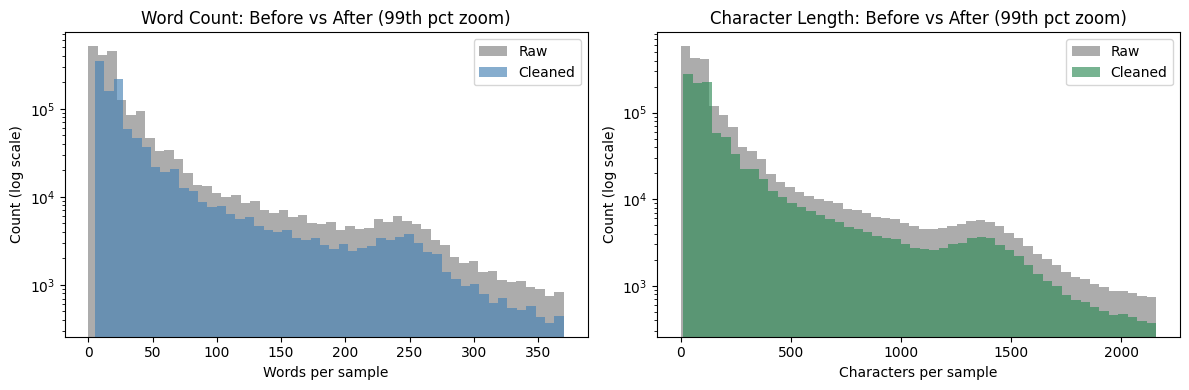


📈 TOP 20 WORDS AFTER CLEANING:
    1. في                   1,415,153 occurrences
    2. من                   793,528 occurrences
    3. على                  661,652 occurrences
    4. ما                   640,730 occurrences
    5. و                    604,874 occurrences
    6. اللي                 434,334 occurrences
    7. باش                  257,832 occurrences
    8. هو                   242,061 occurrences
    9. كان                  232,292 occurrences
   10. مع                   202,713 occurrences
   11. لا                   178,266 occurrences
   12. بش                   162,100 occurrences
   13. هي                   159,167 occurrences
   14. أن                   155,674 occurrences
   15. أو                   142,828 occurrences
   16. هذا                  130,522 occurrences
   17. شنو                  127,005 occurrences
   18. ولا                  117,423 occurrences
   19. الجملة               116,590 occurrences
   20. برشة                 116,022 occurrences


In [42]:
# ============================================================================
# STEP 3: ANALYZE BEFORE VS AFTER CLEANING
# ============================================================================

import matplotlib.pyplot as plt
from data_cleaning import classify_text_type

# Build comparable profiles for raw and cleaned data
raw_profile = df_raw.copy()
raw_profile["text"] = raw_profile["text"].astype(str)
raw_profile["word_count"] = raw_profile["text"].apply(lambda x: len(x.split()))
raw_profile["char_length"] = raw_profile["text"].apply(len)
raw_profile["has_numbers"] = raw_profile["text"].astype(str).str.contains(r'\d', regex=True)

clean_profile = df_cleaned.copy()
clean_profile["has_numbers"] = clean_profile["text"].astype(str).str.contains(r'\d', regex=True)

print("\n📊 BEFORE VS AFTER CLEANING")
print("=" * 60)
print(f"Raw samples:      {len(raw_profile):,}")
print(f"Cleaned samples:  {len(clean_profile):,}")
print(f"Removed samples:  {len(raw_profile) - len(clean_profile):,}")
print(f"Retention rate:   {100 * len(clean_profile) / len(raw_profile):.1f}%")
print(f"\nSamples with numbers in raw data:    {raw_profile['has_numbers'].sum():,}")
print(f"Samples with numbers in cleaned data: {clean_profile['has_numbers'].sum():,}")

# Script composition before/after
raw_types = raw_profile["text"].apply(classify_text_type).value_counts()
clean_types = clean_profile["type"].value_counts() if "type" in clean_profile.columns else pd.Series(dtype=int)

print("\nRaw text types:")
print(raw_types)
print("\nCleaned text types (should be only arabic):")
print(clean_types)

# Use percentile caps to avoid extreme outliers flattening the histogram scale
wc_cap = max(5, int(raw_profile["word_count"].quantile(0.99)))
cc_cap = max(20, int(raw_profile["char_length"].quantile(0.99)))
print(f"\nPlot caps (99th percentile) -> words: {wc_cap}, chars: {cc_cap}")

raw_wc_plot = raw_profile[raw_profile["word_count"] <= wc_cap]["word_count"]
clean_wc_plot = clean_profile[clean_profile["word_count"] <= wc_cap]["word_count"]
raw_cc_plot = raw_profile[raw_profile["char_length"] <= cc_cap]["char_length"]
clean_cc_plot = clean_profile[clean_profile["char_length"] <= cc_cap]["char_length"]

# Visual comparison (zoomed + log count scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_wc_plot, bins=50, color="gray", alpha=0.65, label="Raw")
axes[0].hist(clean_wc_plot, bins=50, color="steelblue", alpha=0.65, label="Cleaned")
axes[0].set_title("Word Count: Before vs After (99th pct zoom)")
axes[0].set_xlabel("Words per sample")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(raw_cc_plot, bins=50, color="gray", alpha=0.65, label="Raw")
axes[1].hist(clean_cc_plot, bins=50, color="seagreen", alpha=0.65, label="Cleaned")
axes[1].set_title("Character Length: Before vs After (99th pct zoom)")
axes[1].set_xlabel("Characters per sample")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📈 TOP 20 WORDS AFTER CLEANING:")
top_words = get_top_words(clean_profile, text_col="text", top_n=20)
for i, (word, count) in enumerate(top_words, 1):
    print(f"   {i:2d}. {word:20s} {count:,} occurrences")

In [43]:
# ============================================================================
# STEP 4: CALCULATE TOKEN STATISTICS
# ============================================================================

try:
    from transformers import AutoTokenizer
    
    print("\n📊 TOKENIZATION STATISTICS")
    print("Loading tokenizer for token counting...")
    
    # Use a multilingual model compatible with Arabic
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    
    total_tokens_arabic = count_tokens(clean_profile, tokenizer, text_col="text")
    
    print(f"\n✅ Arabic-only dataset:")
    print(f"   Samples: {len(clean_profile):,}")
    print(f"   Total tokens: {total_tokens_arabic:,}")
    print(f"   Avg tokens/sample: {total_tokens_arabic / len(clean_profile):.0f}")
     
except Exception as e:
    print(f"⚠️  Could not load tokenizer: {e}")
    print("   You can calculate tokens later with your specific tokenizer")

KeyboardInterrupt: 

In [44]:
# ============================================================================
# STEP 5: SAVE PROCESSED DATA
# ============================================================================

# Create output directory if needed
output_dir = Path("C:\\Users\\user\\OneDrive\\Bureau\\PFA\\tunisian-dialogue-system\\llm\\data\\processed")

print("\n💾 SAVING PROCESSED DATASETS...")

# Save main dataset (Arabic-only)
output_file_arabic = output_dir / "tunisian_arabic_clean.parquet"
clean_profile.to_parquet(output_file_arabic)
print(f"✅ Saved: {output_file_arabic}")
print(f"   Size: {output_file_arabic.stat().st_size / 1e9:.2f} GB")


# Save metadata
metadata = {
    "source": "Stage 1 - Data Collection",
    "raw_samples": len(df_raw),
    "cleaned_samples": len(df_cleaned),
    "arabic_only_samples": len(df_cleaned),
    "cleaning_date": pd.Timestamp.now().isoformat(),
    "sources": [
        "atakaboudi/Dialect_of_Tunisia-Work_Collection",
        "tunis-ai/tunisian-msa-parallel-corpus",
        "linagora/Tunisian_Derja_Dataset (12 splits)"
    ]
}

metadata_file = output_dir / "metadata.json"
with open(metadata_file, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Saved metadata: {metadata_file}")

print("\n" + "="*60)
print("🎉 STAGE 1: DATA COLLECTION COMPLETE!")


💾 SAVING PROCESSED DATASETS...
✅ Saved: C:\Users\user\OneDrive\Bureau\PFA\tunisian-dialogue-system\llm\data\processed\tunisian_arabic_clean.parquet
   Size: 0.18 GB
✅ Saved metadata: C:\Users\user\OneDrive\Bureau\PFA\tunisian-dialogue-system\llm\data\processed\metadata.json

🎉 STAGE 1: DATA COLLECTION COMPLETE!
